<a href="https://colab.research.google.com/github/micahsmithh/ece1395-pitching-classification/blob/main/pitching_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aidan Uher and Micah Smith: ECE 1395 Final Project

This project will be focused on using data from Major League Baseball pitcher's pitches and using machine learning to build a model that can predict pitch type.

## Data Loading and Preprocessing

### Loading CSV

The data used is from Baseball Savant, a website that compiles an extensive amount of data from the MLB for teams, pitchers, batters, etc. The data being used is stored in csv format and can be found in the project GitHub.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial.distance import cdist
from sklearn.preprocessing import LabelEncoder
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
import time
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import mutual_info_classif

In [62]:

file_path = 'https://raw.githubusercontent.com/micahsmithh/ece1395-pitching-classification/main/input/pitch_movement_2025.csv'

In [63]:
pitch_data = pd.read_csv(file_path)

In [64]:
pitch_data.head()

,year,"last_name, first_name",pitcher_id,team_name,team_name_abbrev,pitch_hand,avg_speed,pitches_thrown,total_pitches,pitches_per_game,...,league_break_z,diff_z,rise,pitcher_break_z_induced,pitcher_break_x,league_break_x,diff_x,tail,percent_rank_diff_z,percent_rank_diff_x
0,2025,"Peralta, Freddy",642547,Brewers,MIL,R,94.8,1651,3086,19.049383,...,-15.1,1.2,8.0,16.8,4.6,-8.3,-3.7,-45.0,0.791762,0.098398
1,2025,"Gausman, Kevin",592332,Blue Jays,TOR,R,94.5,1627,3030,18.703704,...,-14.6,0.5,3.0,16.8,11.1,-7.4,3.7,50.0,0.622426,0.899314
2,2025,"Ray, Robbie",592662,Giants,SF,L,93.6,1593,3069,18.944444,...,-14.8,1.5,10.0,18.2,8.2,-6.9,1.3,19.0,0.848970,0.649886
3,2025,"Nelson, Ryne",669194,D-backs,AZ,R,95.7,1526,2466,15.222222,...,-13.3,2.5,19.0,19.2,3.2,-6.7,-3.4,-52.0,0.956522,0.121281
4,2025,"Parker, Mitchell",680730,Nationals,WSH,L,93.0,1501,2705,16.697531,...,-14.4,0.6,4.0,18.0,5.8,-6.3,-0.5,-9.0,0.645309,0.414188


### Removing Rare Pitches

In [65]:
# Pitch proportions
print(pitch_data['pitch_type'].value_counts(normalize=True) * 100)


pitch_type
FF    21.834497
SL    15.503490
SI    15.353938
CH    13.310070
CU    11.266201
FC     9.172483
ST     8.823529
FS     4.137587
SV     0.548355
FO     0.049850
Name: proportion, dtype: float64


In [66]:
pitch_data = pitch_data[~pitch_data['pitch_type'].isin(['SV', 'FO'])]
print(pitch_data['pitch_type'].value_counts(normalize=True) * 100)

pitch_type
FF    21.965898
SL    15.596790
SI    15.446339
CH    13.390171
CU    11.334002
FC     9.227683
ST     8.876630
FS     4.162487
Name: proportion, dtype: float64


In [67]:
print(pitch_data['pitch_type_name'].value_counts(normalize=True) * 100)

pitch_type_name
4-Seam Fastball    21.965898
Slider             15.596790
Sinker             15.446339
Changeup           13.390171
Curveball          11.334002
Cutter              9.227683
Sweeper             8.876630
Split-Finger        4.162487
Name: proportion, dtype: float64


### Preparing Data for Models and Feature Inspection

In [68]:
le = LabelEncoder()
pitch_data['pitch_hand'] = le.fit_transform(pitch_data['pitch_hand'])

In [97]:
#Define feature space
features = ['avg_speed', 'pitcher_break_z_induced', 'pitcher_break_x', 'pitch_hand', 'rise', 'tail']

#Features and labels
X = pitch_data[features]
y = pitch_data['pitch_type']

#Verify
print(X.shape)
print(y.shape)

(1994, 6)
(1994,)


                   Feature  MI Score
2          pitcher_break_x  0.807089
1  pitcher_break_z_induced  0.739068
3                     tail  0.564673
0                avg_speed  0.000000


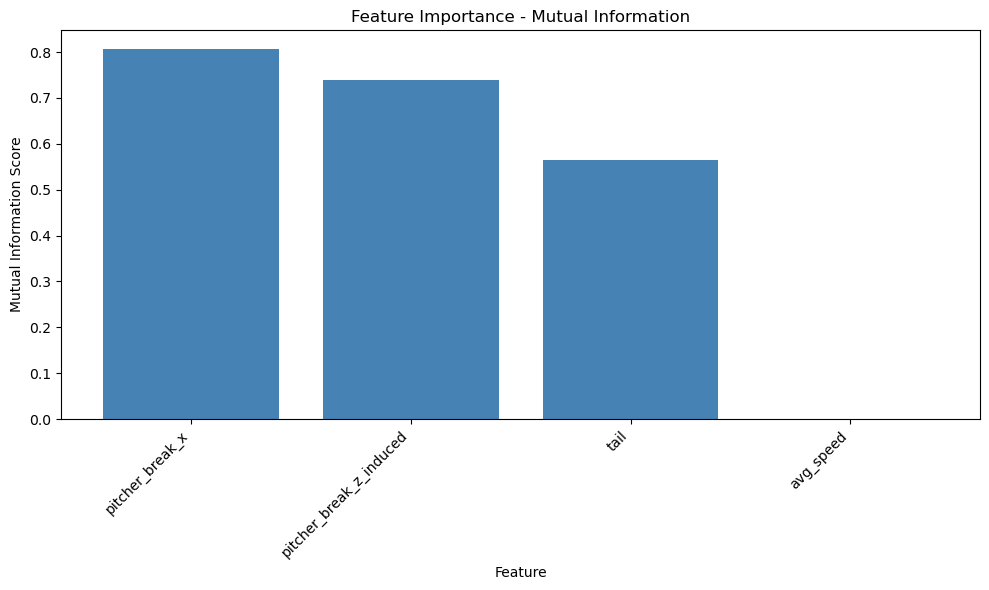

In [122]:
mi_scores = mutual_info_classif(X, y)

mi_df = pd.DataFrame({
    'Feature': features,
    'MI Score': mi_scores
}).sort_values('MI Score', ascending=False)

print(mi_df)

plt.figure(figsize=(10, 6))
plt.bar(mi_df['Feature'], mi_df['MI Score'], color='steelblue')
plt.xlabel('Feature')
plt.ylabel('Mutual Information Score')
plt.title('Feature Importance - Mutual Information')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

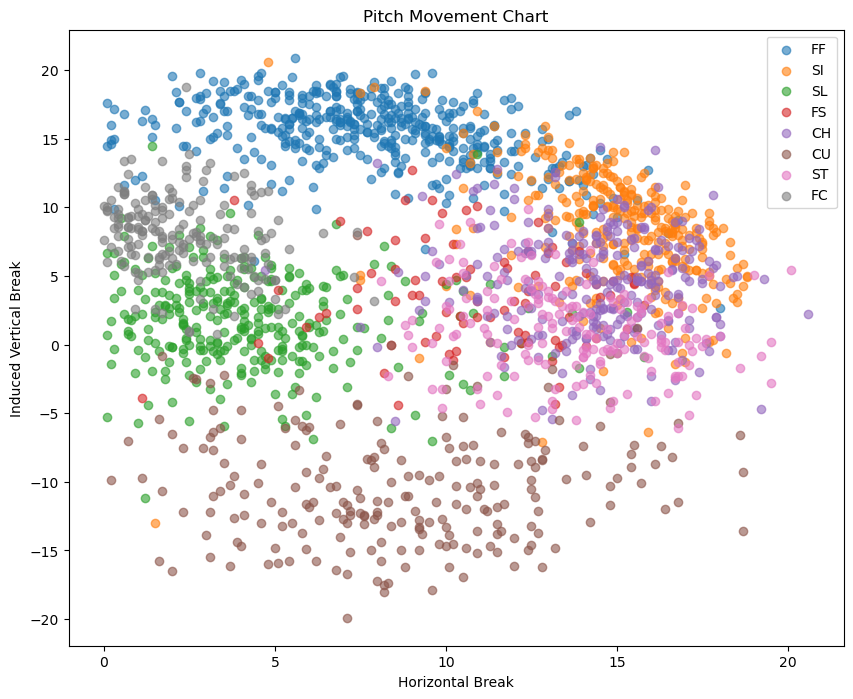

In [99]:
fig, ax = plt.subplots(figsize=(10, 8))

for pitch in pitch_data['pitch_type'].unique():
    subset = pitch_data[pitch_data['pitch_type'] == pitch]
    ax.scatter(subset['pitcher_break_x'], subset['pitcher_break_z_induced'], label=pitch, alpha=0.6)

ax.set_xlabel('Horizontal Break')
ax.set_ylabel('Induced Vertical Break')
ax.set_title('Pitch Movement Chart')
ax.legend()
plt.show()

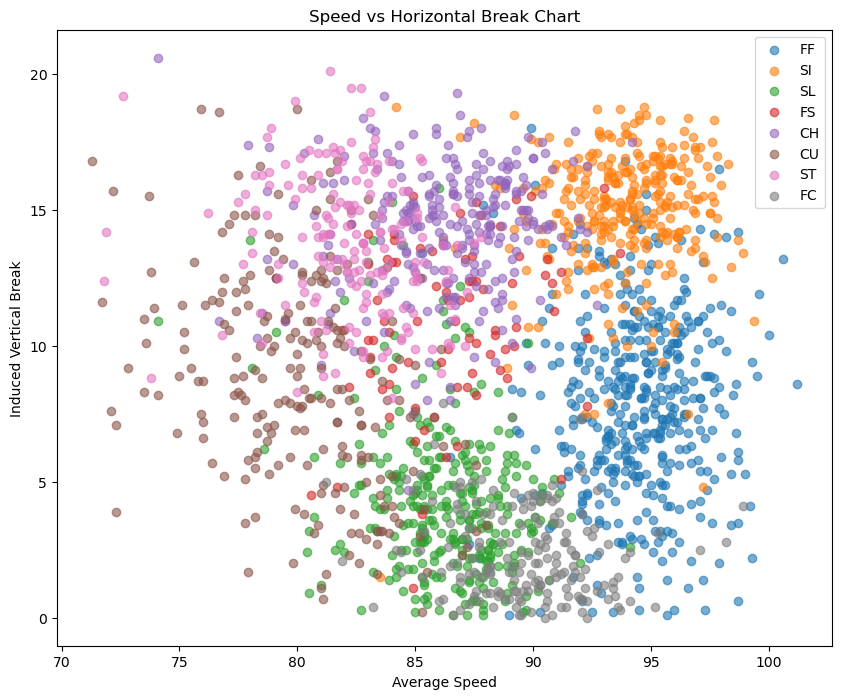

In [100]:
fig, ax = plt.subplots(figsize=(10, 8))

for pitch in pitch_data['pitch_type'].unique():
    subset = pitch_data[pitch_data['pitch_type'] == pitch]
    ax.scatter(subset['avg_speed'], subset['pitcher_break_x'], label=pitch, alpha=0.6)

ax.set_xlabel('Average Speed')
ax.set_ylabel('Induced Vertical Break')
ax.set_title('Speed vs Horizontal Break Chart')
ax.legend()
plt.show()

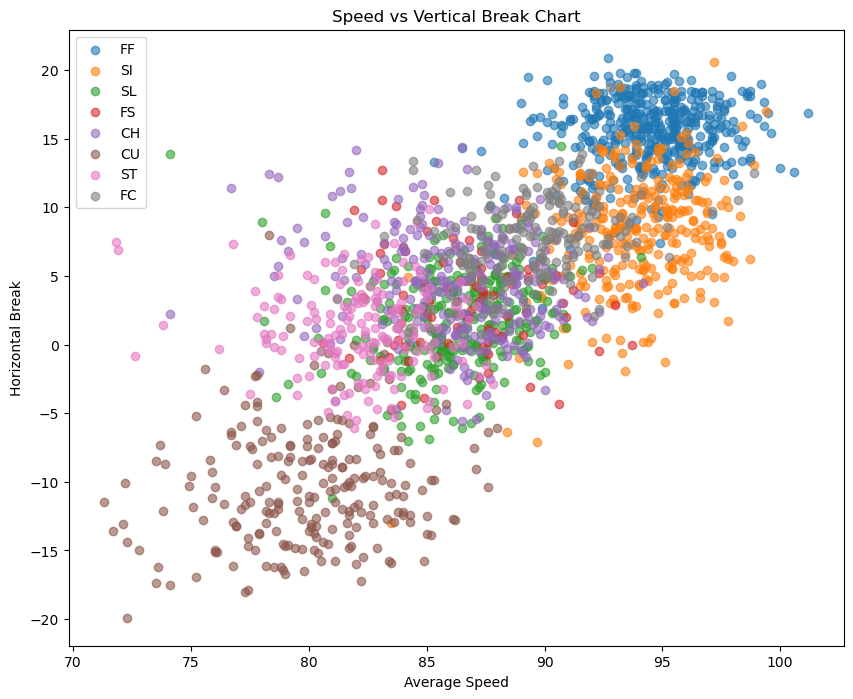

In [101]:
fig, ax = plt.subplots(figsize=(10, 8))

for pitch in pitch_data['pitch_type'].unique():
    subset = pitch_data[pitch_data['pitch_type'] == pitch]
    ax.scatter(subset['avg_speed'], subset['pitcher_break_z_induced'], label=pitch, alpha=0.6)

ax.set_xlabel('Average Speed')
ax.set_ylabel('Horizontal Break')
ax.set_title('Speed vs Vertical Break Chart')
ax.legend()
plt.show()

In [124]:
# Convert pitch_hand to binary: R=1, L=0
pitch_data['pitch_hand_bin'] = pitch_data['pitch_hand'].astype(str).apply(lambda x: 1 if x.upper() == 'R' else 0)

# Features
X = pitch_data[['avg_speed', 'pitcher_break_z_induced', 'pitcher_break_x', 'tail']].values

# Target
y = pitch_data['pitch_type'].values

print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)

Feature matrix X shape: (1994, 4)
Target vector y shape: (1994,)


### Data Splitting

In [125]:
D = 39
np.random.seed(D)
m = X.shape[0]


indices = np.random.permutation(m)
split = int(0.9 * m)

# Indices for train/test
train_idx = indices[:split]
test_idx = indices[split:]

# Split data
X_train = X[train_idx]
y_train = y[train_idx]
X_test = X[test_idx]
y_test = y[test_idx]

### Standarization

In [126]:
scaler = StandardScaler()

# Standardize Data from X_train and apply same transform to X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression

### Logistic Regression Functions

In [127]:
def sigmoid(z):
    """
    Compute the sigmoid of z.

    Parameters:
    z : array_like
        Input value(s), can be scalar, vector, or matrix

    Returns:
    g : array_like
        Sigmoid of z, same shape as input
    """
    # TODO: Implement sigmoid function
    g =  1 / (1 + np.exp(-z))  # TODO
    return g

In [128]:
def costFunction(theta, X, y):
    """
    Compute the cost for logistic regression.

    Parameters:
    theta : array_like
        Parameters of shape (n+1,)
    X : array_like
        Feature matrix of shape (m, n+1) with bias column
    y : array_like
        Labels of shape (m,)

    Returns:
    J : float
        The cost
    """
    m = len(y)

    # TODO: Compute hypothesis h = sigmoid(X @ theta)
    h = sigmoid(X @ theta)  # TODO

    # Added clipping because of warning in toy dataset that log(0) occurred
    h = np.clip(h, 1e-15, 1-1e-15)

    # TODO: Compute cost using the formula
    # J = -(1/m) * sum(y*log(h) + (1-y)*log(1-h))
    # Hint: Use np.log() and be careful with element-wise operations
    J = -(1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))  # TODO

    return J


def gradFunction(theta, X, y):
    """
    Compute the gradient for logistic regression.

    Parameters:
    theta : array_like
        Parameters of shape (n+1,)
    X : array_like
        Feature matrix of shape (m, n+1) with bias column
    y : array_like
        Labels of shape (m,)

    Returns:
    grad : array_like
        Gradient of shape (n+1,)
    """
    m = len(y)

    # TODO: Compute hypothesis
    h = sigmoid(X @ theta)  # TODO

    # TODO: Compute gradient

    grad = 1/m *(X.T @ (h-y))   # TODO

    return grad

In [129]:
def trainOneVsAll(X_train, y_train, random_state=0):
    """
    Train multiple binary logistic regression classifiers using one-vs-all approach.

    Parameters:
    X_train : array_like
        Training features of shape (m, n+1) with bias column
    y_train : array_like
        Training labels of shape (m,)
    random_state : int
        Random seed for reproducibility

    Returns:
    models : list
        List of trained LogisticRegression models
    classes : array_like
        Array of unique class labels
    """
    # Find unique classes
    classes = np.unique(y_train)
    num_classes = len(classes)

    # Initialize list for models
    models = []

    # Train one classifier per class
    for c in range(num_classes):
        current_class = classes[c]

        # TODO: Create binary labels (1 if y_train == current_class, else 0)
        y_binary = (y_train == current_class).astype(int)  # TODO

        # TODO: Train logistic regression model
        mdl = LogisticRegression(random_state=random_state, max_iter=1000).fit(X_train, y_binary)  # TODO: LogisticRegression(random_state=random_state, max_iter=1000).fit(X_train, y_binary)

        models.append(mdl)
        print(f"Trained classifier for class {current_class}")

    return models, classes

In [130]:
def predictOneVsAll(models, classes, X_test):
    """
    Predict class labels using trained one-vs-all classifiers.

    Parameters:
    models : list
        List of trained LogisticRegression models
    classes : array_like
        Array of unique class labels
    X_test : array_like
        Test features of shape (d, n+1)

    Returns:
    y_pred : array_like
        Predicted class labels of shape (d,)
    probas : array_like
        Probability matrix of shape (d, num_classes)
    """
    num_classes = len(models)
    num_samples = X_test.shape[0]

    # Initialize probability matrix
    probas = np.zeros((num_samples, num_classes))

    # Get probabilities from each classifier
    for c in range(num_classes):
        # TODO: Get probability of positive class from classifier c
        # Hint: models[c].predict_proba(X_test) returns probabilities for class 0 and class 1
        # You want the probability of class 1 (positive class), which is column index 1
        proba = models[c].predict_proba(X_test)
        probas[:, c] = proba[:, 1]  # TODO: Which column of proba?

    # TODO: Find class with highest probability for each sample
    # Hint: Use np.argmax()
    class_indices = np.argmax(probas, axis=1)  # TODO: Axis is 1 because we need to find maximum in each row

    # TODO: Convert indices to actual class labels
    y_pred = classes[class_indices]  # TODO: classes[class_indices]

    return y_pred, probas

In [131]:
def confusionMatrix(y_test, y_pred_test):
    # Encode labels to integers
    le = LabelEncoder()
    
    # Encode labels Predictions
    y_test_enc = le.fit_transform(y_test)
    y_pred_enc = le.transform(y_pred_test)
    
    # Compute confusion matrix
    cm = confusion_matrix(y_test_enc, y_pred_enc)
    
    # Display with pitch names
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title("Pitch Types Confusion Matrix")
    plt.show()

### One vs All Linear Regression

In [132]:
# Train one-vs-all classifier
models, classes = trainOneVsAll(X_train, y_train, random_state=D)

# Make predictions on training data
y_pred_train, _ = predictOneVsAll(models, classes, X_train)

# Make predictions on testing data
y_pred_test, _ = predictOneVsAll(models, classes, X_test)

# Compute accuracies
train_accuracy = np.sum(y_pred_train == y_train) / len(y_pred_train) * 100  # TODO
test_accuracy = np.sum(y_pred_test == y_test) / len(y_pred_test) * 100   # TODO

print(f"\nResults:")
print(f"Number of classes: {len(classes)}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Training accuracy: {train_accuracy:.2f}%")
print(f"Testing accuracy: {test_accuracy:.2f}%")

Trained classifier for class CH
Trained classifier for class CU
Trained classifier for class FC
Trained classifier for class FF
Trained classifier for class FS
Trained classifier for class SI
Trained classifier for class SL
Trained classifier for class ST

Results:
Number of classes: 8
Training samples: 1794
Testing samples: 200
Training accuracy: 76.70%
Testing accuracy: 78.00%


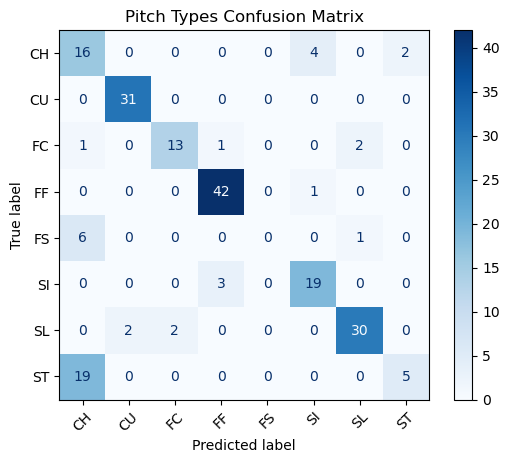

In [133]:
confusionMatrix(y_test, y_pred_test)

### Logistic Regression with Standardization

In [134]:
# Train one-vs-all classifier
models, classes = trainOneVsAll(X_train_scaled, y_train, random_state=D)

# Make predictions on training data
y_pred_train, _ = predictOneVsAll(models, classes, X_train_scaled)

# Make predictions on testing data
y_pred_test, _ = predictOneVsAll(models, classes, X_test_scaled)

# Compute accuracies
train_accuracy = np.sum(y_pred_train == y_train) / len(y_pred_train) * 100  # TODO
test_accuracy = np.sum(y_pred_test == y_test) / len(y_pred_test) * 100   # TODO

print(f"\nResults:")

print(f"Training accuracy: {train_accuracy:.2f}%")
print(f"Testing accuracy: {test_accuracy:.2f}%")

Trained classifier for class CH
Trained classifier for class CU
Trained classifier for class FC
Trained classifier for class FF
Trained classifier for class FS
Trained classifier for class SI
Trained classifier for class SL
Trained classifier for class ST

Results:
Training accuracy: 75.98%
Testing accuracy: 78.00%


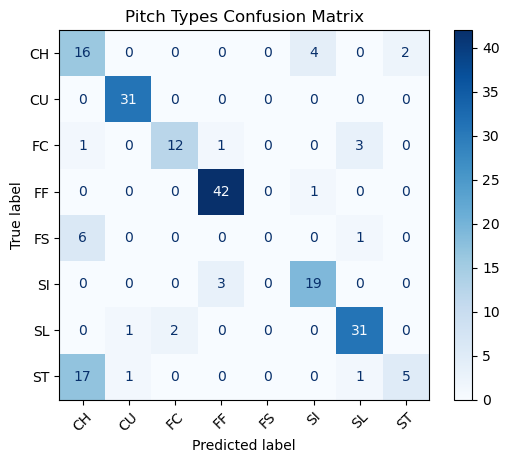

In [135]:
confusionMatrix(y_test, y_pred_test)

## KNN

### Functions

In [136]:
def create_k_folds(n_samples, k, random_seed):
    np.random.seed(random_seed)

    # Shuffle Indices
    indices = np.random.permutation(n_samples)

    # Split into folds
    folds = np.array_split(indices, k)
    
    return folds

In [137]:
def cross_validate_knn(X, y, k_neighbors, k_folds, fold_indices):

    fold_accuracies = []
    
    for i in range(k_folds):
        # Fold i is test
        test_index = fold_indices[i]

        # Rest of folds are training
        train_index = np.hstack([fold_indices[j] for j in range(k_folds) if i != j])

        # Split Data
        X_train = X[train_index]
        y_train = y[train_index]
        X_test = X[test_index]
        y_test = y[test_index]

        # Train KNN Model
        KNN_model = KNeighborsClassifier(n_neighbors=k_neighbors)
        KNN_model.fit(X_train, y_train)

        # Predict Test Data
        test_prediction = KNN_model.predict(X_test)

        # Get accuracy for fold
        fold_accuracy = np.mean(test_prediction == y_test)
        fold_accuracies.append(fold_accuracy)

    # Compute Average Accuracy across all folds
    avg_accuracy = np.mean(fold_accuracies)

    return avg_accuracy, fold_accuracies

In [138]:
# Weighted KNN
def weighted_knn(X_train, y_train, X_test, sigma):

    # Compute Distances
    distances = cdist(X_test, X_train)

    # Compute Weights
    weights = np.exp( -(distances**2) / (2 * sigma**2) )

    # Unique Classes
    classes = np.unique(y_train)

    # Prediction
    y_pred = np.empty(len(X_test), dtype=object)

    # Loop Through all test points to predict
    for i in range(X_test.shape[0]):
        class_weights = []

        # Get all class weights
        for cl in classes:

            # Compute class weight at test point
            class_mask = (y_train == cl)
            class_weight = np.sum(weights[i, class_mask])
            class_weights.append(class_weight)

        # Make Prediction and add to np array
        y_pred[i] = classes[np.argmax(class_weights)]

    return y_pred

In [139]:
def find_k(X, y, k_values, seed):
    # Create folds
    folds = create_k_folds(len(X), 5, seed)

    # Tuple holding (k, accuracy)
    best_k = (k_values[0], 0)
    
    # Loop over all k values
    for k in k_values:

        # Find accuracy of k
        avg_accuracy, fold_accuracies = cross_validate_knn(X, y, k, 5, folds)
        
        # Change k if top accuracy
        if avg_accuracy > best_k[1]:
            best_k = (k, avg_accuracy) 

    return best_k

### Testing KNN

In [140]:
k_values = np.arange(1, 50, 2)

# Find ks
k, accuracy = find_k(X, y, k_values, D)

# Table
print("Dataset Size   Optimal k   Accuracy at Optimal K")
print("-------------------------------------------------")
print(f"100%             {k}           {accuracy*100:.2f}%")

Dataset Size   Optimal k   Accuracy at Optimal K
-------------------------------------------------
100%             3           83.35%


In [141]:
optimal_k = 41
KNN_model = KNeighborsClassifier(n_neighbors=optimal_k)
KNN_model.fit(X_train_scaled, y_train)

# Predict Test Data
y_pred_test = KNN_model.predict(X_test_scaled)

accuracy = np.mean(y_pred_test == y_test)
print(f"Accuracy = {accuracy*100:0.2f}%")

Accuracy = 88.50%


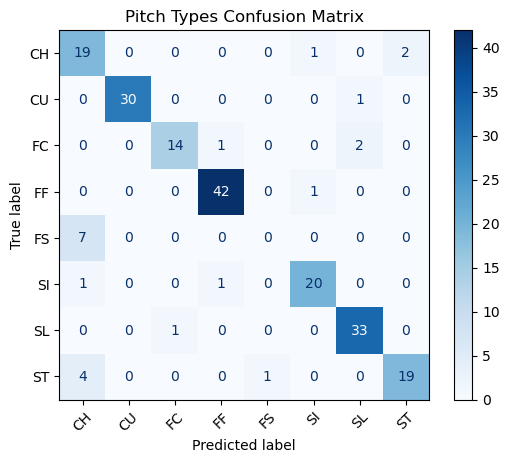

In [142]:
confusionMatrix(y_test, y_pred_test)

Fixed most of the sweeper changeup missclassifications

### Testing Weighted KNN

My weighted Implementation Accuracy: 76.50%
Scikit's Accuracy: 89.50%


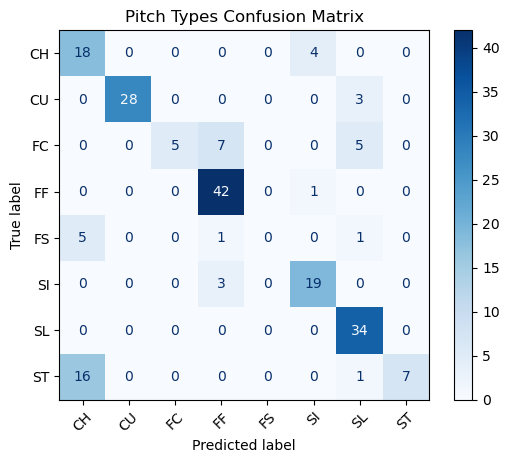

In [143]:
# Compute predictions
y_pred = weighted_knn(X_train_scaled, y_train, X_test_scaled, 1.0)
weighted_accuracy = np.mean(y_pred == y_test)

# Scikit's
KNN_model = KNeighborsClassifier(weights='distance', n_neighbors=41)
KNN_model.fit(X_train_scaled, y_train)

# Predict Test Data
scikit_prediction = KNN_model.predict(X_test_scaled)
scikit_accuracy = np.mean(scikit_prediction == y_test)

print(f"My weighted Implementation Accuracy: {weighted_accuracy*100:0.2f}%")
print(f"Scikit's Accuracy: {scikit_accuracy*100:0.2f}%")


confusionMatrix(y_test, y_pred)

## Support Vector Machine

Use different types of kernels and one-vs-all against one-vs-one classifiers to see what produces the highest accuracy. Standardized values are used

In [144]:
#Lists to compare
accuracies = []
times = []
cv_means = []
cv_stds = []

#Define models
models = [
    OneVsOneClassifier(SVC(kernel='linear', C=1)),
    OneVsRestClassifier(SVC(kernel='linear', C=1)),
    OneVsOneClassifier(SVC(kernel='poly', degree=3, C=1)),
    OneVsRestClassifier(SVC(kernel='poly', degree=3, C=1)),
    OneVsOneClassifier(SVC(kernel='rbf', C=1)),
    OneVsRestClassifier(SVC(kernel='rbf', C=1))
]

#For all models, get cross validation accuracies
for svm in models:
    #Training time
    start = time.time()
    svm.fit(X_train_scaled, y_train)
    end = time.time()
    times.append(end - start)

    #Test accuracy
    y_pred = svm.predict(X_test_scaled)
    acc = np.mean(y_pred == y_test)
    accuracies.append(acc)

    #Cross validation scores
    cv_scores = cross_val_score(svm, X_train_scaled, y_train, cv=5)
    cv_means.append(cv_scores.mean())
    cv_stds.append(cv_scores.std())

#Display table
print("Training Time (seconds):")
print(f"{''}\t\t\t {'One-vs-One'}\t {'One-vs-All'}")
print(f"{'Linear'}\t\t\t {times[0]:.4f}\t\t {times[1]:.4f}")
print(f"{'Polynomial (3rd order)'}\t {times[2]:.4f}\t\t {times[3]:.4f}")
print(f"{'RBF'}\t\t\t {times[4]:.4f}\t\t {times[5]:.4f}")

print("\nTest Accuracy (%):")
print(f"{''}\t\t\t {'One-vs-One'}\t {'One-vs-All'}")
print(f"{'Linear'}\t\t\t {accuracies[0]*100:.2f}\t\t {accuracies[1]*100:.2f}")
print(f"{'Polynomial (3rd order)'}\t {accuracies[2]*100:.2f}\t\t {accuracies[3]*100:.2f}")
print(f"{'RBF'}\t\t\t {accuracies[4]*100:.2f}\t\t {accuracies[5]*100:.2f}")

print("\nCV Mean Accuracy (%):")
print(f"{''}\t\t\t {'One-vs-One'}\t {'One-vs-All'}")
print(f"{'Linear'}\t\t\t {cv_means[0]*100:.2f}\t\t {cv_means[1]*100:.2f}")
print(f"{'Polynomial (3rd order)'}\t {cv_means[2]*100:.2f}\t\t {cv_means[3]*100:.2f}")
print(f"{'RBF'}\t\t\t {cv_means[4]*100:.2f}\t\t {cv_means[5]*100:.2f}")

print("\nCV Std (%):")
print(f"{''}\t\t\t {'One-vs-One'}\t {'One-vs-All'}")
print(f"{'Linear'}\t\t\t {cv_stds[0]*100:.2f}\t\t {cv_stds[1]*100:.2f}")
print(f"{'Polynomial (3rd order)'}\t {cv_stds[2]*100:.2f}\t\t {cv_stds[3]*100:.2f}")
print(f"{'RBF'}\t\t\t {cv_stds[4]*100:.2f}\t\t {cv_stds[5]*100:.2f}")

Training Time (seconds):
			 One-vs-One	 One-vs-All
Linear			 0.0702		 0.0768
Polynomial (3rd order)	 0.0664		 0.2659
RBF			 0.0614		 0.1278

Test Accuracy (%):
			 One-vs-One	 One-vs-All
Linear			 89.50		 73.50
Polynomial (3rd order)	 91.00		 89.00
RBF			 94.00		 93.00

CV Mean Accuracy (%):
			 One-vs-One	 One-vs-All
Linear			 88.80		 70.34
Polynomial (3rd order)	 85.12		 83.67
RBF			 89.85		 87.18

CV Std (%):
			 One-vs-One	 One-vs-All
Linear			 0.89		 2.71
Polynomial (3rd order)	 0.80		 0.84
RBF			 0.77		 0.57


Based on these accuracy results, One-vs-One performs the best accross all kernels. The single best SVM combination is using RBF with a One-vs-All classifier, although its performance is similar to our One-vs-One. This is shown with the accuracy values and the cross validation. Using this combination, we can test different C values to see what would give the optimal accuracy.

In [145]:
#Values to test
C_values = [0.01, 0.1, 1, 10, 100]
results = []

#For all values create a new classifier
for C in C_values:
    svm = OneVsRestClassifier(SVC(kernel='rbf', C=C))
    #Fit the model on training data
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)
    #Calculate and append accuracy
    acc = np.mean(y_pred == y_test)
    results.append((C, acc*100))
    print(f"C={C}: {acc*100:.2f}%")

C=0.01: 76.50%
C=0.1: 87.00%
C=1: 93.00%
C=10: 94.00%
C=100: 95.00%


A C value of 1 still provides the highest accuracy. This is the model that should be used. A confusion matrix will help to see misclassified pitches 

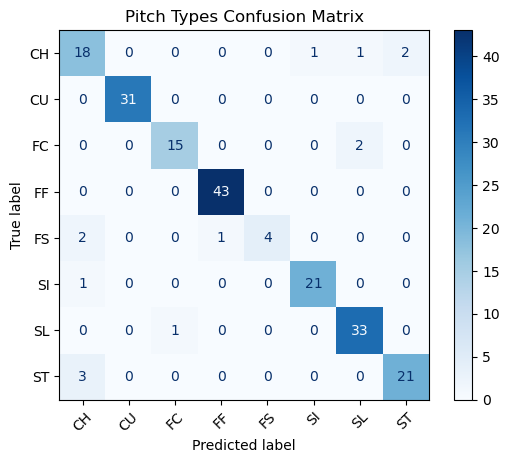

In [146]:
svm = OneVsRestClassifier(SVC(kernel='rbf', C=1))
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)
confusionMatrix(y_test, y_pred)